# Libraries

In [105]:
import xarray as xr
import rioxarray
import rasterio
import os
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt

In [3]:
main_dir = "C:/Users/msali/Desktop/Python/physics-guided-gwl"
data_path = f"{main_dir}/data"

# Data

In [50]:
piemonte_shp = gpd.read_file(f"{data_path}/shapefile/piemonte_admin_boundaries.shp", engine='fiona')
piemonte_shp = piemonte_shp.to_crs('epsg:4326')

# remove the small enclaved Cuneo area inside Torino province
piemonte_shp = piemonte_shp[:-1]

In [57]:
wtd_geodf = gpd.read_file(f"{data_path}/shapefile/underground_wtd_sensor_roi.shp",
                                            engine='fiona')
wtd_geodf = wtd_geodf.to_crs('epsg:4326')

In [109]:
era5_land = xr.open_dataset(f"{data_path}/era5land_2000_2024_weekly.nc").rio.write_crs('epsg:4326')

In [110]:
era5_land["tp"] = era5_land["tp"] * 1000
era5_land["t2m"] = era5_land["t2m"] - 273.15

In [111]:
era5_land

<xarray.Dataset> Size: 7MB
Dimensions:      (time: 1201, lat: 12, lon: 16)
Coordinates:
  * lat          (lat) float64 96B 45.35 45.25 45.15 45.05 ... 44.45 44.35 44.25
  * lon          (lon) float64 128B 6.625 6.725 6.825 ... 7.926 8.026 8.126
  * time         (time) datetime64[ns] 10kB 2000-12-31 2001-01-07 ... 2023-12-31
    spatial_ref  int64 8B 0
Data variables:
    t2m          (time, lat, lon) float32 922kB -6.694 -7.737 ... 2.997 4.271
    smlt         (time, lat, lon) float32 922kB ...
    swvl1        (time, lat, lon) float32 922kB ...
    swvl2        (time, lat, lon) float32 922kB ...
    swvl3        (time, lat, lon) float32 922kB ...
    swvl4        (time, lat, lon) float32 922kB ...
    pev          (time, lat, lon) float32 922kB ...
    tp           (time, lat, lon) float32 922kB 6.091 5.877 5.8 ... 0.1378 0.21
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-28T22:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [112]:
nwioi = xr.open_dataset(f"{data_path}/meteo_bucket_model_snowpack_ROI_1958_2023.nc").resample(time="W", label = "left").mean().rio.write_crs('epsg:4326')

In [113]:
nwioi = nwioi.sel(time = slice(np.datetime64("2000-12-31"),None))

In [114]:
nwioi

<xarray.Dataset> Size: 7MB
Dimensions:      (time: 1200, lat: 9, lon: 12)
Coordinates:
  * lon          (lon) float64 96B 6.688 6.813 6.938 7.063 ... 7.813 7.938 8.063
  * lat          (lat) float64 72B 45.31 45.19 45.06 44.94 ... 44.56 44.44 44.31
  * time         (time) datetime64[ns] 10kB 2000-12-31 2001-01-07 ... 2023-12-24
    spatial_ref  int64 8B 0
Data variables:
    prec         (time, lat, lon) float32 518kB 2.918 3.042 ... 0.06875 0.1887
    tmax         (time, lat, lon) float32 518kB -0.9357 -0.6723 ... 7.273 8.815
    tmin         (time, lat, lon) float32 518kB -3.904 -4.079 ... 2.762 3.275
    tmean        (time, lat, lon) float32 518kB -2.42 -2.376 ... 5.017 6.045
    prain        (time, lat, lon) float32 518kB 0.2007 0.2359 ... 0.05145 0.1631
    psnow        (time, lat, lon) float32 518kB 2.717 2.806 ... 0.0173 0.02558
    et_0         (time, lat, lon) float64 1MB 0.6513 0.7024 ... 1.208 1.406
    r_a          (time, lat, lon) float64 1MB 10.75 10.75 10.75 ... 11.0 11.0
    snowpack     (time, lat, lon) float64 1MB 76.71 63.85 74.83 ... 0.0 0.004671
    snowmelt     (time, lat, lon) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue May 14 07:41:14 2024: cdo -r settaxis,1957-12-01,12:00,...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

# Temporal Statistics

In [115]:
era5_land.mean()

<xarray.Dataset> Size: 40B
Dimensions:      ()
Coordinates:
    spatial_ref  int64 8B 0
Data variables:
    t2m          float32 4B 7.474
    smlt         float32 4B 0.0004941
    swvl1        float32 4B 0.3789
    swvl2        float32 4B 0.3801
    swvl3        float32 4B 0.3768
    swvl4        float32 4B 0.4162
    pev          float32 4B -0.001888
    tp           float32 4B 1.743

In [93]:
nwioi.mean()

<xarray.Dataset> Size: 56B
Dimensions:   ()
Data variables:
    prec      float32 4B 2.526
    tmax      float32 4B 13.5
    tmin      float32 4B 5.66
    tmean     float32 4B 9.582
    prain     float32 4B 2.043
    psnow     float32 4B 0.4834
    et_0      float64 8B 5.212
    r_a       float64 8B 26.42
    snowpack  float64 8B 10.87
    snowmelt  float64 8B 1.505

In [67]:
query_sensor = ["Savigliano","Racconigi","Scalenghe","Tarantasca","Carmagnola"]

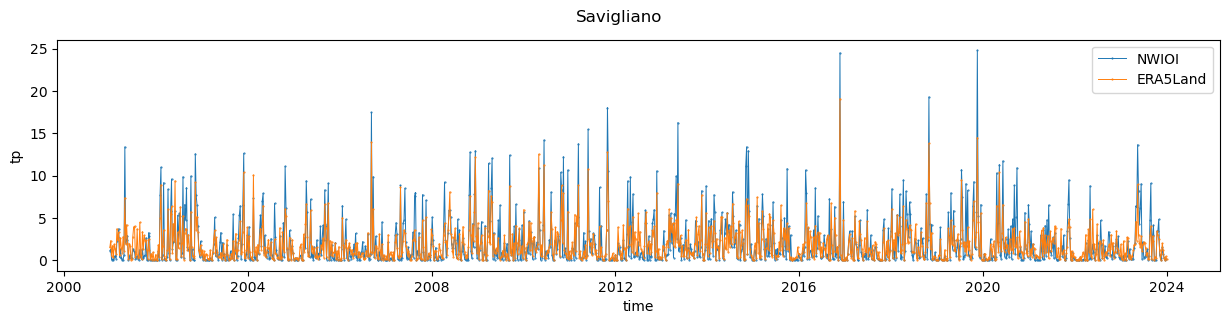

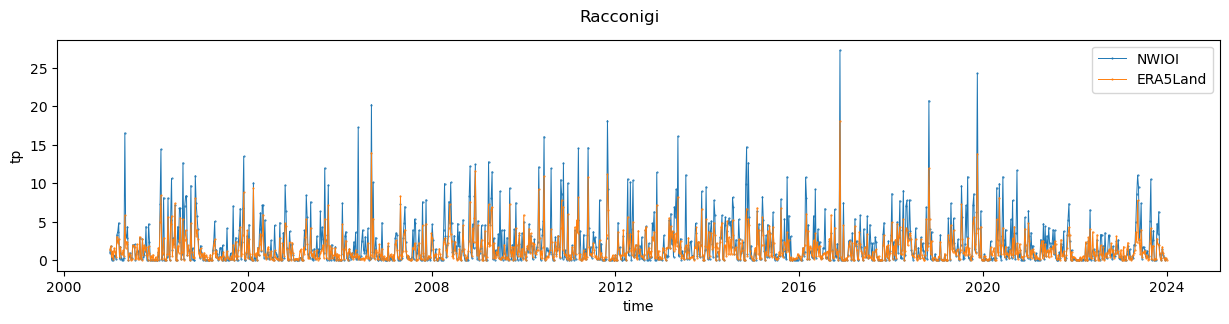

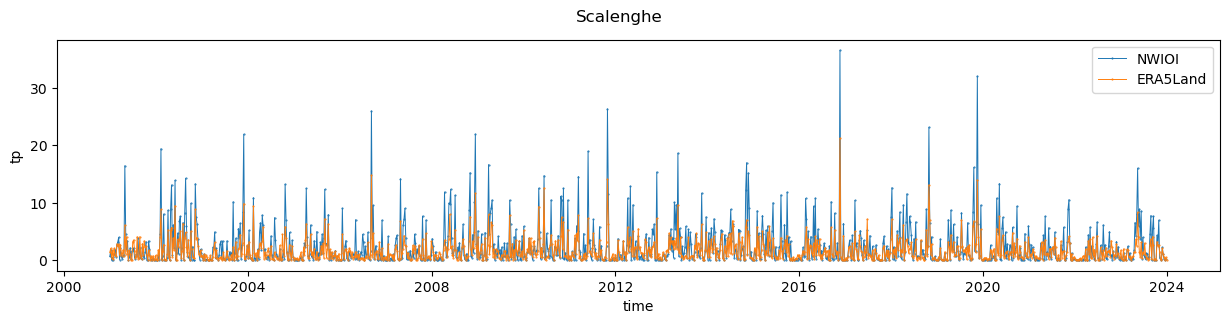

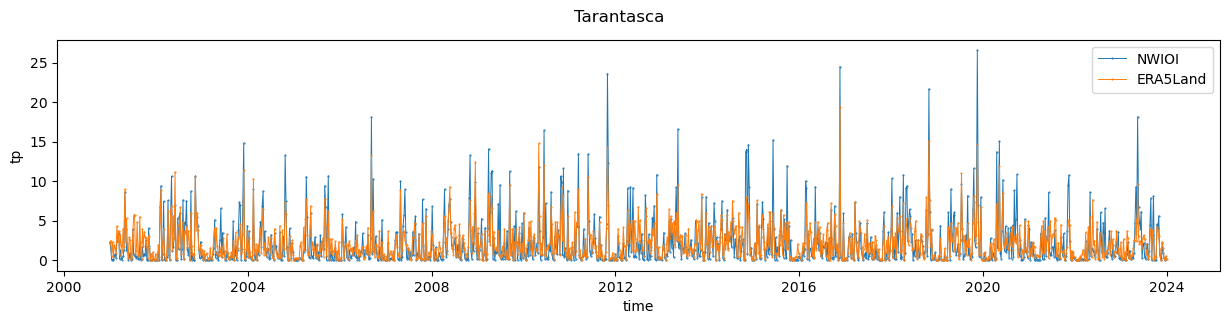

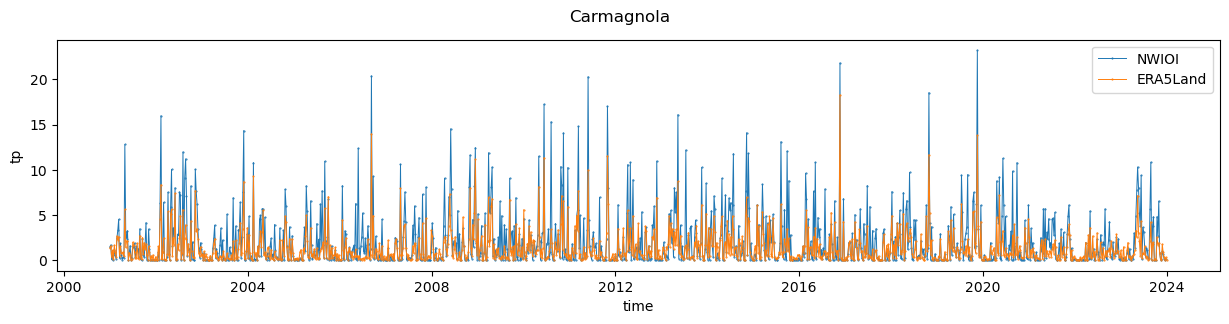

In [94]:
for i in range(len(query_sensor)):
    
    x = wtd_geodf.loc[wtd_geodf["munic"] == query_sensor[i],"geometry"].x.iloc[0]
    y = wtd_geodf.loc[wtd_geodf["munic"] == query_sensor[i],"geometry"].y.iloc[0]

    era5_ts = era5_land.sel(lat = y, lon = x, method="nearest")
    nwioi_ts = nwioi.sel(lat = y, lon = x, method="nearest")
    
    fig, ax = plt.subplots(1,1, figsize = (15,3))
    fig.suptitle(query_sensor[i])
    
    nwioi_ts["prec"].plot(ax = ax, marker = "o", label = "NWIOI", lw = 0.7, markersize = 0.5)
    era5_ts["tp"].plot(ax = ax, marker = "o", label = "ERA5Land", lw = 0.7, markersize = 0.5)
    
    ax.set_title("")
    
    ax.legend()

# Spatial Statistics

In [31]:
era5_land.mean(dim = "time")["tp"].min().values

array(1.21496987)

In [41]:
prec_vmin = min(era5_land.mean(dim = "time")["tp"].min(), nwioi.mean(dim = "time")["prec"].min())
prec_vmax = max(era5_land.mean(dim = "time")["tp"].max(), nwioi.mean(dim = "time")["prec"].max())

<Axes: title={'center': 'ARPA NWIOI'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

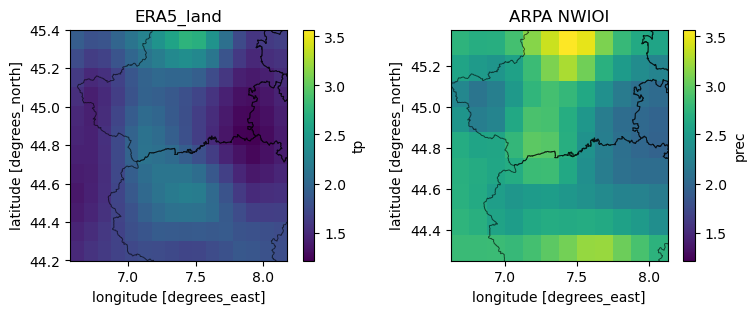

In [55]:
fig, ax = plt.subplots(1,2, figsize = (9,3))

era5_land.mean(dim = "time")["tp"].plot(ax = ax[0], vmin = prec_vmin, vmax = prec_vmax)
ax[0].set_title("ERA5_land")
piemonte_shp.boundary.plot(color = 'Black', linewidth = 0.7, alpha = 0.6, ax = ax[0], label = "Administrative bounds")


nwioi.mean(dim = "time")["prec"].plot(ax = ax[1], vmin = prec_vmin, vmax = prec_vmax)
ax[1].set_title("ARPA NWIOI")
piemonte_shp.boundary.plot(color = 'Black', linewidth = 0.7, alpha = 0.6, ax = ax[1], label = "Administrative bounds")

In [38]:
print("Prec ERA5 Land min:", era5_land.mean(dim = "time")["tp"].min().values.round(3))
print("Prec NWIOI min:", nwioi.mean(dim = "time")["prec"].min().values.round(3))

Prec ERA5 Land min: 1.215
Prec NWIOI min: 1.952


In [39]:
print("Prec ERA5 Land max:", era5_land.mean(dim = "time")["tp"].max().values.round(3))
print("Prec NWIOI max:", nwioi.mean(dim = "time")["prec"].max().values.round(3))

Prec ERA5 Land max: 2.737
Prec NWIOI max: 3.569


In [42]:
temp_vmin = min(era5_land.mean(dim = "time")["t2m"].min(), nwioi.mean(dim = "time")["tmean"].min())
temp_vmax = max(era5_land.mean(dim = "time")["t2m"].max(), nwioi.mean(dim = "time")["tmean"].max())

<Axes: title={'center': 'ARPA NWIOI'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

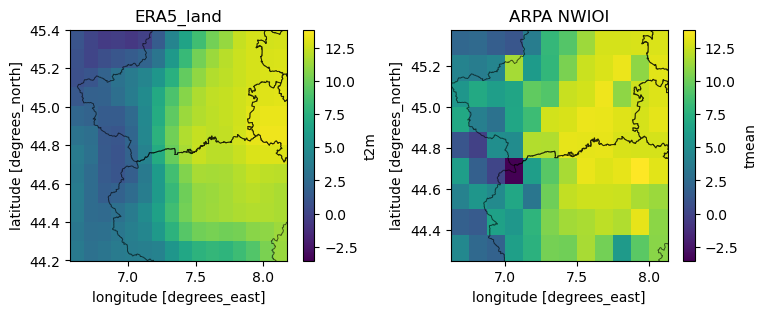

In [56]:
fig, ax = plt.subplots(1,2, figsize = (9,3))

era5_land.mean(dim = "time")["t2m"].plot(ax = ax[0], vmin = temp_vmin, vmax = temp_vmax)
ax[0].set_title("ERA5_land")
piemonte_shp.boundary.plot(color = 'Black', linewidth = 0.7, alpha = 0.6, ax = ax[0], label = "Administrative bounds")

nwioi.mean(dim = "time")["tmean"].plot(ax = ax[1], vmin = temp_vmin, vmax = temp_vmax)
ax[1].set_title("ARPA NWIOI")
piemonte_shp.boundary.plot(color = 'Black', linewidth = 0.7, alpha = 0.6, ax = ax[1], label = "Administrative bounds")


In [44]:
print("Temp ERA5 Land min:", era5_land.mean(dim = "time")["t2m"].min().values.round(3))
print("Temp NWIOI min:", nwioi.mean(dim = "time")["tmean"].min().values.round(3))

Temp ERA5 Land min: -0.685
Temp NWIOI min: -3.54


In [45]:
print("Temp ERA5 Land max:", era5_land.mean(dim = "time")["t2m"].max().values.round(3))
print("Temp NWIOI max:", nwioi.mean(dim = "time")["tmean"].max().values.round(3))

Temp ERA5 Land max: 13.401
Temp NWIOI max: 13.865


# Metrics

In [101]:
era5_land["tp"].sel(time = nwioi.time)

<xarray.DataArray 'tp' (time: 1200, lat: 12, lon: 16)> Size: 922kB
array([[[6.09145641e+00, 5.87689638e+00, 5.80046368e+00, ...,
         1.94629180e+00, 2.24731851e+00, 2.54536176e+00],
        [6.05346632e+00, 5.71859455e+00, 5.31133509e+00, ...,
         1.78738916e+00, 2.06695676e+00, 2.36423540e+00],
        [6.15485430e+00, 5.47621584e+00, 4.96268940e+00, ...,
         1.62337244e+00, 1.88922608e+00, 2.18101358e+00],
        ...,
        [6.10469007e+00, 6.23668957e+00, 6.10303497e+00, ...,
         2.11165667e+00, 2.34370160e+00, 2.64371443e+00],
        [6.27481270e+00, 6.68116426e+00, 6.58089018e+00, ...,
         2.93450904e+00, 3.15192938e+00, 3.48243117e+00],
        [6.31649160e+00, 6.80240870e+00, 6.73717785e+00, ...,
         3.59460187e+00, 3.78801894e+00, 4.12879229e+00]],

       [[1.48339200e+00, 1.50848591e+00, 1.58615994e+00, ...,
         1.62859762e+00, 1.68448079e+00, 1.72445178e+00],
        [1.32008886e+00, 1.32361555e+00, 1.37582302e+00, ...,
         1.49973750e+00, 1.51275933e+00, 1.53846192e+00],
        [1.15034139e+00, 1.10422993e+00, 1.14941180e+00, ...,
         1.33303297e+00, 1.32971835e+00, 1.32736385e+00],
...
        [3.32980324e-03, 2.55646766e-03, 2.20548036e-03, ...,
         8.35460611e-04, 3.44371935e-03, 9.63469036e-03],
        [1.40354445e-03, 1.25725381e-03, 1.17690745e-03, ...,
         4.61885054e-03, 8.63962248e-03, 2.30570585e-02],
        [7.42763106e-04, 6.65666943e-04, 6.31920411e-04, ...,
         6.38450496e-03, 1.68969966e-02, 3.27520892e-02]],

       [[5.41896820e-01, 5.25233209e-01, 4.73267466e-01, ...,
         8.87583494e-01, 7.30208218e-01, 5.51230907e-01],
        [4.58452761e-01, 4.37878996e-01, 3.88190567e-01, ...,
         6.02671266e-01, 5.75685501e-01, 4.28512454e-01],
        [4.08090025e-01, 3.58397007e-01, 3.06500524e-01, ...,
         2.84198135e-01, 2.67431527e-01, 2.58203506e-01],
        ...,
        [3.62898111e-01, 3.75956446e-01, 3.63360554e-01, ...,
         9.35856774e-02, 1.38763219e-01, 2.19763294e-01],
        [3.82580727e-01, 4.15769994e-01, 4.09095109e-01, ...,
         1.71005383e-01, 2.25429162e-01, 4.18449312e-01],
        [3.98319304e-01, 4.34001207e-01, 4.25599277e-01, ...,
         2.20438048e-01, 3.54641825e-01, 5.64025581e-01]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 96B 45.35 45.25 45.15 45.05 ... 44.45 44.35 44.25
  * lon      (lon) float64 128B 6.625 6.725 6.825 6.925 ... 7.926 8.026 8.126
  * time     (time) datetime64[ns] 10kB 2000-12-31 2001-01-07 ... 2023-12-24

In [121]:
tot_prec_bias = (era5_land["tp"].sel(time = nwioi.time).rio.reproject_match(nwioi["prec"]) - nwioi["prec"]).mean().values
print("Total Precipitation BIAS: ", tot_prec_bias)

temp_bias = (era5_land["t2m"].sel(time = nwioi.time).rio.reproject_match(nwioi["tmean"]) - nwioi["tmean"]).mean().values
print("Mean Temperature BIAS: ", temp_bias)

Total Precipitation BIAS:  -0.78096753
Mean Temperature BIAS:  -1.9416131
